In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Remontar
# drive.flush_and_unmount()

In [15]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Forecast')

import numpy as np
import pandas as pd
import random

import plot_dashes
import processing as prc
import models

from sklearn.metrics import mean_squared_error


Datasets

In [16]:
'''
    Info Base - melbmin.txt

    10 Anos des temperatura mínima diária em Melbourne, Austrália.
    De 1980-12-31 à 1990-12-31

'''
X = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets/melbmin.txt', sep='\t', decimal='.')

Pré-processamento

In [17]:
data = X.iloc[:, 0].values

n_lags = 5
X, y = prc.window_lags(data, n_lags)

Classe

In [18]:
mlp_2 = models.MLP(X, y)

In [19]:
results = mlp_2.train_model()

# 'lst_results'
# 'pred_test'
# 'pred_test_denom'
# 'test_window'
# 'test_target'
# 'best_rna'
# 'best_errors_list'

Forecast - MLP

In [ ]:
# MLP Params
solver = 'sgd' # adam, sgd
hidden_neurons = [10,20,30,40]
learning_rate = [0.1, 0.01, 0.001]
activation=['logistic','tanh','relu']
#[[10, 0.1, 'relu'],[10, 0.1, 'logistic']... [40, 0.001, 'tanh']]
jumps =  10

lst_results_mlp, pred_test_mlp, pred_test_denom_mlp, X_test, y_test, best_rna, best_errors = models.forecast_mlp(
    X,
    y,
    solver,
    hidden_neurons,
    learning_rate,
    activation,
    jumps
)

mlp = np.array(pred_test_denom_mlp)

Forecast - SVR

In [6]:
# SVR
C_values=[0.1, 1, 10, 100] # Penalidade por erro
epsilon_values=[0.01, 0.05, 0.1]
gamma_values=['scale', 0.01, 0.1]

lst_results_svr, pred_test_svr, X_test, y_test, best_svr = models.forecast_svr(X, y, C_values, epsilon_values, gamma_values)

svr = np.array(pred_test_svr)

Forecast - RF

In [7]:
n_estimators_values = [50, 100, 200]
max_depth_values = [None, 5, 10, 20]

lst_results_rf, pred_test_rf, X_test, y_test, best_rf = models.forecast_rf(X, y, n_estimators_values, max_depth_values)

rf = np.array(pred_test_rf)

Previsões

In [8]:
P = np.column_stack((mlp, svr, rf))

Lógica Algoritmo Genético

In [ ]:
# Inicialização - Opção usando código na mão

# Aqui pode ser uma classe

rng = np.random.default_rng()

def start_population(max_size):
    '''
    Inicialização
    Criação aleatória de um conjunto de soluções candidatas (população inicial).
    **Aqui vamos criar individuos de forma aleatória para cada um dos modelos que serão utilizados.**

    20 Individuos com espaco de busca de 3 dimensões (3 modelos), 
    de pesos continuos, com valores entre 0 e 1, e a soma dos 
    pesos deve ser igual a 1.

    # # Opção usando NumPy - dirichlet
    # rng = np.random.default_rng()
    # rng.dirichlet([1, 1, 1], size=20)
    
    '''
    population = []
    epsilon = 1e-6

    for _ in range(max_size):

        ind = []

        first_element = random.uniform(epsilon, 0.98)
        second_element = random.uniform(epsilon, 1 - first_element - epsilon)
        third_element = 1 - (first_element + second_element)

        ind = [first_element, second_element, third_element]
        random.shuffle(ind)

        population.append(ind)

    return np.array(population)

def evaluate_population(y_test, y_hat):

    '''
    2. Avaliação
    
    Aplica-se uma função de fitness no conjunto.
    Essa função define o quão boa é cada solução (quanto maior ou menor, melhor — depende do problema).
    Nesse processo, os individuos inicializados serão executados em cada modelo e avaliados de acordo com o resultado do fitness utilizado.
    
    '''
    ind_metrics = []

    for _ in range(y_hat.shape[1]):
        fitness = 1 / mean_squared_error(y_test, y_hat[:,_])
        ind_metrics.append(fitness)

    return ind_metrics

def tournament_selection(population, fitness, size_tournament):
    '''
    # 3. Seleção
    # Alguns dos melhores candidatos são escolhidos.
    # Esses candidatos irão gerar a próxima geração.

    # Distinguir com base na qualidade, permitir que os melhores individuos se tornem pais da próxima geração.

    Processo probabilístico, onde indivíduos com melhor fitness têm maior chance de serem selecionados, mas mesmo os piores têm uma chance (evitando convergência prematura).
    
    '''
    n_population = len( population )
    selected = []

    for _ in range(n_population):
        participants = random.sample( range(len(population)), size_tournament )

        winner = participants[0]
        for i in range(1, size_tournament):
            if fitness[participants[i]] > fitness[winner]:
                winner = participants[i]
        
        selected.append(population[winner])

    return selected


def crossover(selected_parents):
    '''
    Cruzamento (Recombinação)
    
    - A partir de dois ou mais candidatos (pais), são gerados novos indivíduos (filhos). 
    '''
    new_generation = []

    for gen in range(0, len(selected_parents), 2):
        parent_1, parent_2 = selected_parents[gen], selected_parents[gen+1]
        single_point = random.randint(1, len(parent_1) - 1)

        child_1 = np.concatenate((parent_1[:single_point], parent_2[single_point:]))
        child_2 = np.concatenate((parent_2[:single_point], parent_1[single_point:]))
        
        new_generation.extend([child_1, child_2])
    
    return new_generation

def mutation(offspring):
    '''
    Mutação
    - Pequenas alterações aleatórias são introduzidas em alguns indivíduos.
    - Isso ajuda a manter a diversidade genética e evita que o algoritmo fique preso em ótimos locais.

    - Se usarmos child[gene] = random.uniform(0, 1) - Dessa forma eu mudo completamente o Gene, o que teoricamente favorece Exploração, comportamentoo mais agfressivo, diversidade e menos estabilidade

    - Se usarmos child[gene] += random.uniform(-0.001, 0.001) - dessa forma eu favoreço refinamento local, busca gradual, comportamento mais estável, e exploração fina.

    '''
    mutation_rate = 0.1

    for i, child in enumerate(offspring):
        mutation = random.random()

        if mutation < mutation_rate:

            gene = random.randint(0, len(child) - 1)
            child[gene] += random.uniform(-0.001, 0.001)

            child = np.clip(child, 0, None)
            child = child / np.sum(child) # Renormalização para garantir que a soma dos pesos seja igual a 1

            offspring[i] = child
    
    return np.array(offspring)

def renormalizar():
    """
    # Normalização para garantir que a soma dos pesos seja igual a 1?
    # new = child_1 / sum(child_1) 
    De acordo com Domingos, nesse passo eu devo - Garantir que os somatórios dos pesos sejam iguais a 1
    """
    pass

def genetic_algorithm(P, y_test):
    '''
    '''

    W = start_population(20)
    best_ = []

    for generation in range(50):
        y_hat = P @ W.T
        fitness = evaluate_population(y_test, y_hat)
        best_.append((max(fitness)))


        selected = tournament_selection(W, fitness, 3)
        new_generation = crossover(selected)
        W = mutation(new_generation)
    
    y_hat = P @ W.T
    fitness = evaluate_population(y_test, y_hat)
    c

    best_ind = W[best_idx]
    best_fit = fitness[best_idx]

    # best_ind = max(y_hat, key=evaluate_population(y_test, y_hat))
    # fitness = evaluate_population(y_test, y_hat)

    return best_, best_ind, best_fit

    

In [41]:
best_, best_ind, best_fit = genetic_algorithm(P, y_test)

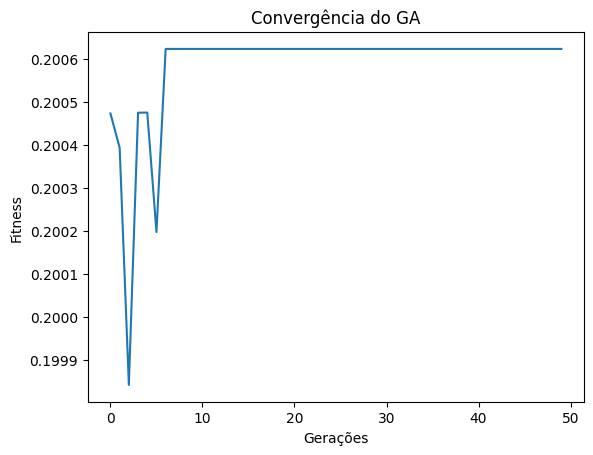

In [48]:
import matplotlib.pyplot as plt

plt.plot(best_)
plt.xlabel("Gerações")
plt.ylabel("Fitness")
plt.title("Convergência do GA")
plt.show()

In [43]:
best_ind

array([0.15396529, 0.36077192, 0.48778807])

In [44]:
best_fit

0.20062311141012215

In [ ]:
# W = start_population(20)
# gen_num = 50

# for gen in range(gen_num):

#     # y_hat = P @ W.T # Devo inserir os novos individuos aqui no W p/calculo do fitness

#     fitness = evaluate_population(y_test, y_hat)


Métricas

In [74]:
plot_dashes.get_metrics_error(y_test, pred_test_denom)

MSE: 5.403773542528819
RMSE: 2.3246018030038647
MAE: 1.8360295940449134
MAPE: 0.21391831278444984


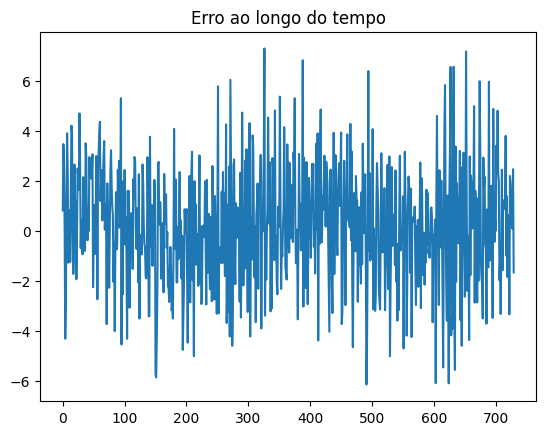

In [75]:
plot_dashes.get_plot_error(y_test, pred_test_denom)

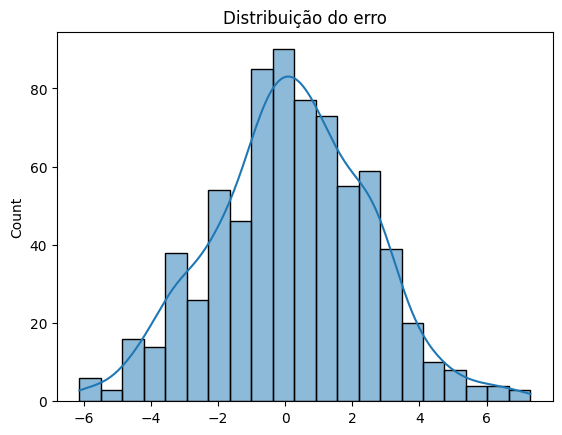

In [76]:
plot_dashes.get_error_distribution(y_test, pred_test_denom)

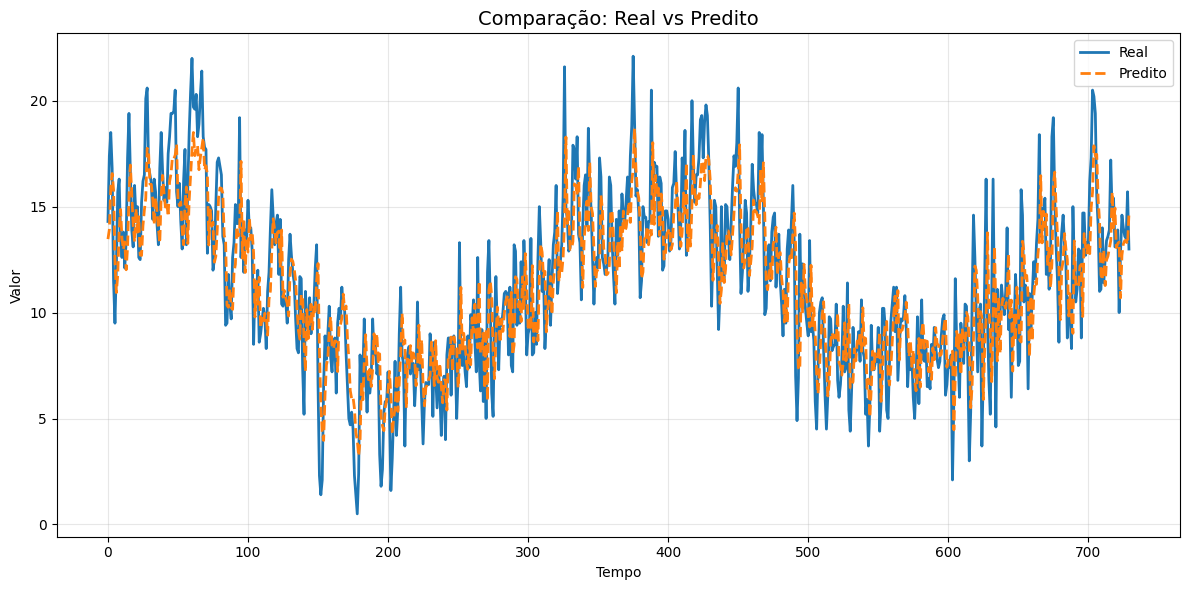

In [77]:
plot_dashes.get_prediction_plot(y_test, pred_test_denom)

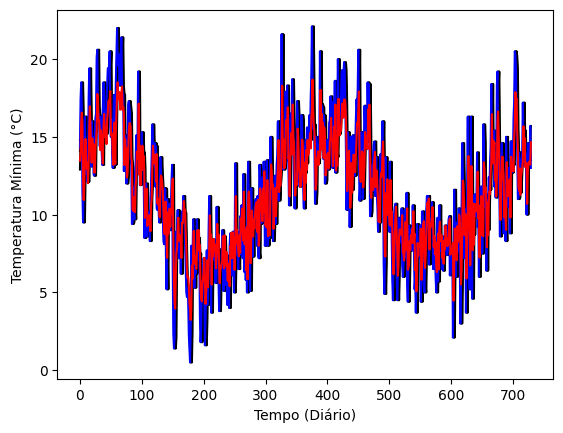

In [78]:
plot_dashes.get_prediction_plot_full(X_test, y_test, pred_test_denom)

Forecast - SVR

In [ ]:
# GA para SVR - No SVR não há pesos para otimizar, mas pode atuar diretamente nos hiperparâmetros (C, epsilon, gamma) para melhorar a performance. O processo é similar ao do MLP, mas o cromossomo representa uma combinação de hiperparâmetros em vez de pesos da rede. O GA busca a melhor combinação que minimize o erro de previsão no conjunto de validação.

# cromossomo = [C, epsilon, gamma]
# fitness    = -RMSE no conjunto de validação
# GA busca a melhor combinação desses três valores

# Sem GA — busca manual 
# for c in [0.1, 1, 10, 100]:
#     for e in [0.01, 0.05, 0.1]:
#         for g in ['scale', 0.01, 0.1]:
#             ...  # 36 combinações fixas

# Com GA — busca contínua e inteligente
# cromossomo = [C=7.3, epsilon=0.032, gamma=0.07]
# GA explora o espaço contínuo, não uma grade fixa

In [ ]:
# # Hiperparâmetros do SVR
# C — penalidade por erro:

# Controla o quanto o modelo penaliza pontos que ficam fora do tubo ε
# C pequeno → modelo mais suave, aceita mais erros, pode underfit
# C grande → modelo mais rígido, tenta acertar tudo, pode overfit
# Valores típicos para começar: [0.1, 1, 10, 100]

# epsilon — largura do tubo de tolerância:

# Pontos dentro do tubo não contribuem para o erro — são ignorados
# Epsilon pequeno → tubo estreito, modelo mais sensível a cada ponto
# Epsilon grande → tubo largo, modelo mais suave
# Valores típicos: [0.01, 0.05, 0.1, 0.5]
# Regra prática: comece com 5-10% do desvio padrão do y de treino

# gamma — curvatura do kernel RBF:

# Controla o quanto cada ponto de treino influencia a curva
# 'scale' → 1 / (n_features * X.var()) — automático
# Gamma pequeno → curva mais suave, influência mais ampla
# Gamma grande → curva mais irregular, influência localizada
# Valores típicos: ['scale', 0.001, 0.01, 0.1, 1]

In [81]:
C_values=[0.1, 1, 10, 100] # Penalidade por erro
epsilon_values=[0.01, 0.05, 0.1]
gamma_values=['scale', 0.01, 0.1]

lst_results, pred_test, X_test, y_test, best_svr = models.forecast_svr(X, y, C_values, epsilon_values, gamma_values)

In [82]:
best_svr

SVR(C=1)

Métricas

In [83]:
plot_dashes.get_metrics_error(y_test, pred_test)

MSE: 5.232639654426024
RMSE: 2.2874963725492603
MAE: 1.8218151012826758
MAPE: 0.21460075596885606


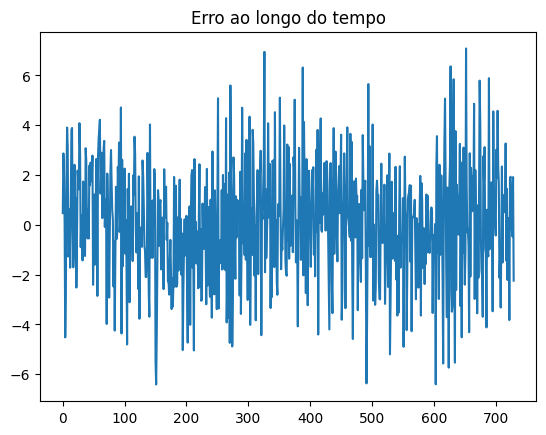

In [84]:
plot_dashes.get_plot_error(y_test, pred_test)

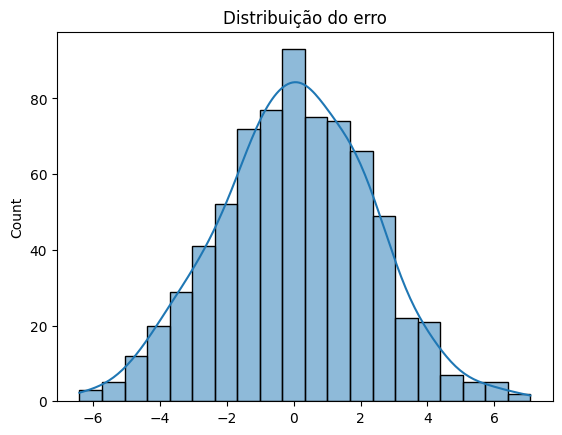

In [85]:
plot_dashes.get_error_distribution(y_test, pred_test)

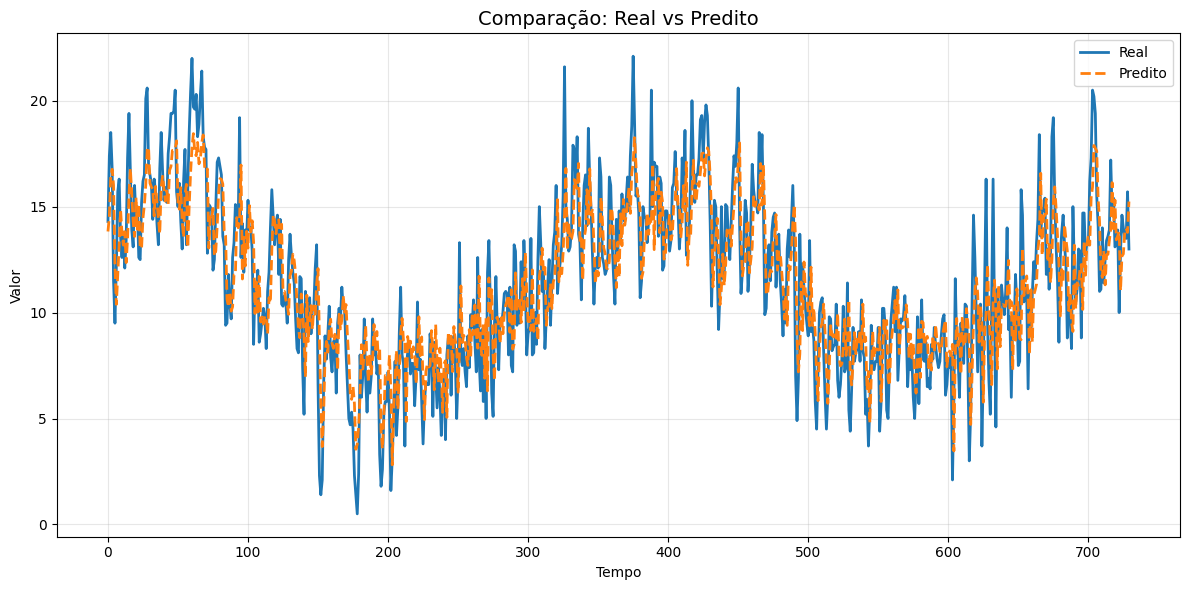

In [86]:
plot_dashes.get_prediction_plot(y_test, pred_test)

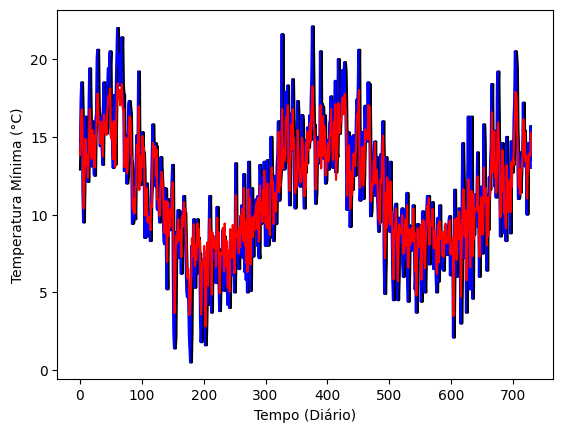

In [87]:
plot_dashes.get_prediction_plot_full(X_test, y_test, pred_test)

Forecast - RF

In [88]:
# cromossomo = [n_estimators, max_depth, min_samples_split]
# fitness    = -RMSE no conjunto de validação

In [89]:
# # Hiperparâmetros do RF 

# n_estimators — número de árvores:

# Mais árvores = modelo mais estável, mas mais lento
# Abaixo de 50 costuma ser instável, acima de 500 o ganho é marginal
# Valores típicos: [50, 100, 200, 500]

# max_depth — profundidade máxima de cada árvore:

# None → árvore cresce até separar todos os pontos (overfitting em geral)
# Valores pequenos (3–10) regularizam o modelo
# Valores típicos: [None, 5, 10, 20]

In [90]:
n_estimators_values = [50, 100, 200]
max_depth_values = [None, 5, 10, 20]

lst_results, pred_test, X_test, y_test, best_rf = models.forecast_rf(X, y, n_estimators_values, max_depth_values)

In [91]:
best_rf

RandomForestRegressor(max_depth=5, random_state=42)

Métricas

In [92]:
plot_dashes.get_metrics_error(y_test, pred_test)

MSE: 5.259104641782888
RMSE: 2.293273782561273
MAE: 1.82413281383804
MAPE: 0.21289760141557643


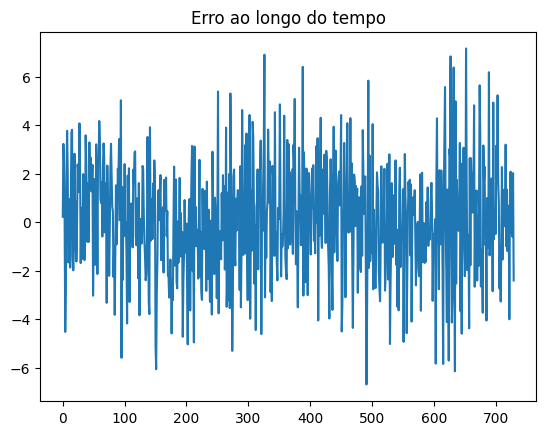

In [93]:
plot_dashes.get_plot_error(y_test, pred_test)

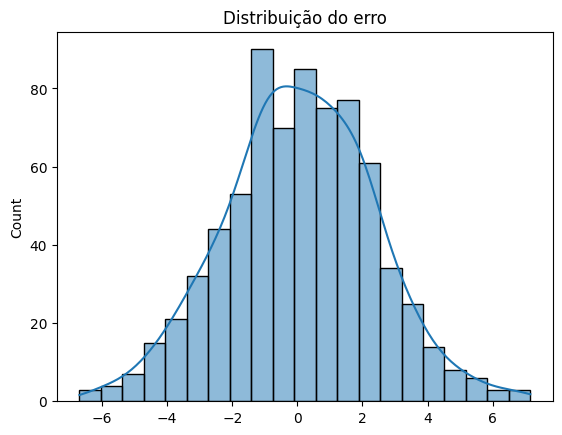

In [94]:
plot_dashes.get_error_distribution(y_test, pred_test)

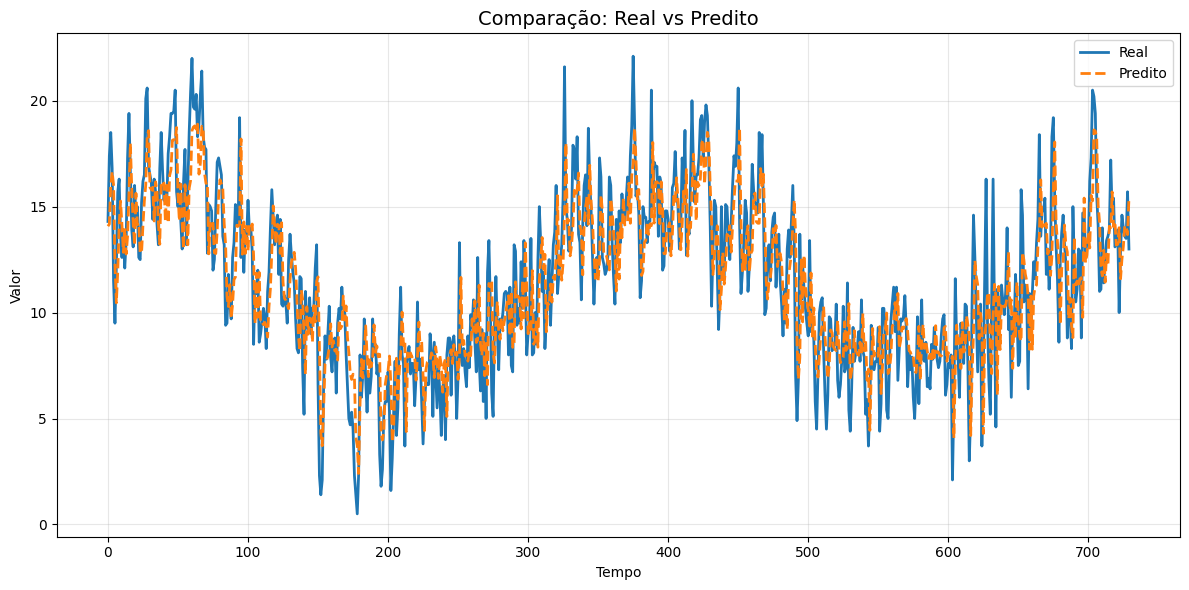

In [95]:
plot_dashes.get_prediction_plot(y_test, pred_test)

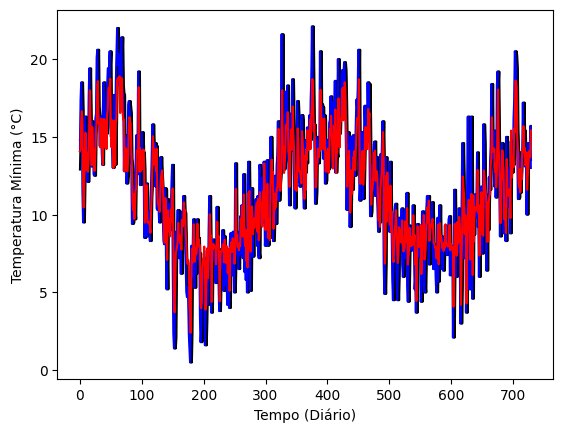

In [96]:
plot_dashes.get_prediction_plot_full(X_test, y_test, pred_test)